# LCZ → Intervention Sankey

Pulls Local Climate Zone (LCZ) pixel counts for a neighbourhood from Google Earth Engine,
joins them to the *LCZ Actions Library* lookup table, ranks interventions by applicable
pixel coverage, and renders a Sankey diagram.

**Data sources**
- LCZ raster: WUDAPT Global LCZ Map via GEE — `projects/sat-io/open-datasets/WUDAPT/global_lcz_map`
- Intervention lookup: `heat_threshold_analysis/data/LCZ_Actions library _Final draft _April 22.csv`
- Neighbourhood boundaries: `data/geobr_salvador_neighbourhoods_2010.gpkg`

**To run for a different neighbourhood:** change `SELECTED_NEIGHBOURHOOD` in the *Configuration* cell only.

In [53]:
import struct
import sqlite3
from pathlib import Path
from typing import Optional

import ee
import pandas as pd
import plotly.graph_objects as go

ee.Initialize(project='tl-cities')

REPO_ROOT = Path().resolve().parent          # heatInsights-notebooks/
DATA_DIR  = REPO_ROOT / 'data'
LCZ_CSV   = REPO_ROOT / 'heat_threshold_analysis' / 'data' / 'LCZ_Actions library _Final draft _April 22.csv'
GPKG_PATH = DATA_DIR / 'geobr_salvador_neighbourhoods_2010.gpkg'

print('GEE initialised')
print('LCZ CSV  :', LCZ_CSV.exists(), LCZ_CSV)
print('GPKG     :', GPKG_PATH.exists(), GPKG_PATH)

GEE initialised
LCZ CSV  : True /Users/martynclark/heatInsights-notebooks/heat_threshold_analysis/data/LCZ_Actions library _Final draft _April 22.csv
GPKG     : True /Users/martynclark/heatInsights-notebooks/data/geobr_salvador_neighbourhoods_2010.gpkg


## LCZ type reference (WUDAPT colour scheme)

In [54]:
# Standard LCZ type metadata — keys are integer raster pixel values.
LCZ_META = {
    1:  {'label': 'Compact high-rise',    'color': '#8c0000'},
    2:  {'label': 'Compact midrise',       'color': '#d10000'},
    3:  {'label': 'Compact low-rise',      'color': '#ff0000'},
    4:  {'label': 'Open high-rise',        'color': '#bf4d00'},
    5:  {'label': 'Open midrise',          'color': '#ff6600'},
    6:  {'label': 'Open low-rise',         'color': '#ff9955'},
    7:  {'label': 'Lightweight low-rise',  'color': '#faee05'},
    8:  {'label': 'Large low-rise',        'color': '#bcbcbc'},
    9:  {'label': 'Sparsely built',        'color': '#ffccaa'},
    10: {'label': 'Heavy industry',        'color': '#555555'},
    11: {'label': 'Dense trees (A)',       'color': '#006a00'},
    12: {'label': 'Scattered trees (B)',   'color': '#00aa00'},
    13: {'label': 'Bush / scrub (C)',      'color': '#648525'},
    14: {'label': 'Low plants (D)',        'color': '#b9db79'},
    15: {'label': 'Bare rock / paved (E)', 'color': '#000000'},
    16: {'label': 'Bare soil / sand (F)',  'color': '#fbf7ae'},
    17: {'label': 'Water (G)',             'color': '#6a6aff'},
}

# Letter suffix used in CSV → integer pixel value
_LETTER_TO_INT = {'A': 11, 'B': 12, 'C': 13, 'D': 14, 'E': 15, 'F': 16, 'G': 17}

print(f'{len(LCZ_META)} LCZ types defined')

17 LCZ types defined


## Build LCZ → intervention lookup from the Actions Library CSV

The CSV has one row per action.  The *Local Climate Zone* column lists which LCZ types
each action applies to (e.g. `"LCZ1, LCZ2, LCZA"`).  We invert this to build a dict
`{lcz_int: [action_name, ...]}`.

In [55]:
def _parse_lcz_codes(lcz_str: str) -> list[int]:
    """Parse a comma-separated LCZ string from the CSV into a list of integer codes."""
    if not isinstance(lcz_str, str) or lcz_str.strip() in ('', 'No Value Available'):
        return []
    codes = []
    for token in lcz_str.split(','):
        token = token.strip()
        if not token.upper().startswith('LCZ'):
            continue
        suffix = token[3:].strip()
        if suffix.isdigit():
            codes.append(int(suffix))
        elif suffix.upper() in _LETTER_TO_INT:
            codes.append(_LETTER_TO_INT[suffix.upper()])
    return codes


def load_lcz_interventions(csv_path: Path) -> dict[int, list[str]]:
    """
    Read the LCZ Actions Library CSV and return an inverted lookup:
        {lcz_int: [action_name_1, action_name_2, ...]}
    """
    # utf-8-sig strips the BOM present in this CSV file
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()

    # Normalise column names defensively
    action_col = next(c for c in df.columns if 'action name' in c.lower())
    lcz_col    = next(c for c in df.columns if 'local climate zone' in c.lower())

    lookup: dict[int, list[str]] = {}
    for _, row in df.dropna(subset=[action_col]).iterrows():
        action = str(row[action_col]).strip()
        codes  = _parse_lcz_codes(str(row.get(lcz_col, '')))
        for code in codes:
            lookup.setdefault(code, []).append(action)

    return lookup


LCZ_INTERVENTIONS = load_lcz_interventions(LCZ_CSV)

all_actions = sorted({a for actions in LCZ_INTERVENTIONS.values() for a in actions})
print(f'Loaded {len(all_actions)} distinct actions across {len(LCZ_INTERVENTIONS)} LCZ types\n')
for lcz_code in sorted(LCZ_INTERVENTIONS):
    meta  = LCZ_META.get(lcz_code, {})
    label = meta.get('label', f'LCZ {lcz_code}')
    print(f'  LCZ {lcz_code:2d} ({label}): {len(LCZ_INTERVENTIONS[lcz_code])} actions')

Loaded 46 distinct actions across 12 LCZ types

  LCZ  1 (Compact high-rise): 31 actions
  LCZ  2 (Compact midrise): 31 actions
  LCZ  3 (Compact low-rise): 31 actions
  LCZ  5 (Open midrise): 30 actions
  LCZ  6 (Open low-rise): 30 actions
  LCZ  8 (Large low-rise): 11 actions
  LCZ  9 (Sparsely built): 3 actions
  LCZ 10 (Heavy industry): 3 actions
  LCZ 11 (Dense trees (A)): 6 actions
  LCZ 12 (Scattered trees (B)): 8 actions
  LCZ 13 (Bush / scrub (C)): 2 actions
  LCZ 14 (Low plants (D)): 7 actions


## Load neighbourhood boundaries from GeoPackage

Reads polygon geometries directly from the GPKG using `sqlite3` + a lightweight WKB parser
(no geopandas dependency).  Returns a dict `{neighbourhood_name: ee.Geometry}`.

In [56]:
def _parse_wkb(data: bytes, offset: int = 0) -> list[list[list[float]]]:
    """
    Parse WKB Polygon or MultiPolygon, returning a list of exterior rings.
    Each ring is a list of [lon, lat] coordinate pairs.
    """
    bo = data[offset]
    fmt = '<' if bo == 1 else '>'
    offset += 1
    wkb_type = struct.unpack_from(fmt + 'I', data, offset)[0]
    offset += 4

    def read_ring(data, offset, fmt):
        n = struct.unpack_from(fmt + 'I', data, offset)[0]
        offset += 4
        pts = []
        for _ in range(n):
            lon, lat = struct.unpack_from(fmt + 'dd', data, offset)
            offset += 16
            pts.append([round(lon, 7), round(lat, 7)])
        return pts, offset

    def read_polygon(data, offset, fmt):
        n_rings = struct.unpack_from(fmt + 'I', data, offset)[0]
        offset += 4
        exterior = None
        for r in range(n_rings):
            ring, offset = read_ring(data, offset, fmt)
            if r == 0:
                exterior = ring
        return exterior, offset

    rings = []
    if wkb_type == 3:   # Polygon
        ext, _ = read_polygon(data, offset, fmt)
        if ext:
            rings.append(ext)
    elif wkb_type == 6: # MultiPolygon
        n_polys = struct.unpack_from(fmt + 'I', data, offset)[0]
        offset += 4
        for _ in range(n_polys):
            sub_bo  = data[offset]
            sub_fmt = '<' if sub_bo == 1 else '>'
            offset += 1
            sub_type = struct.unpack_from(sub_fmt + 'I', data, offset)[0]
            offset += 4
            if sub_type == 3:
                ext, offset = read_polygon(data, offset, sub_fmt)
                if ext:
                    rings.append(ext)
    return rings


def load_neighbourhoods(gpkg_path: Path) -> dict[str, ee.Geometry]:
    """
    Read all neighbourhood polygons from the GeoPackage and return a dict
    mapping name → ee.Geometry.MultiPolygon (or Polygon for single-ring features).
    """
    _ENVELOPE_BYTES = {0: 0, 1: 32, 2: 48, 3: 48, 4: 64}
    neighbourhoods = {}

    conn = sqlite3.connect(str(gpkg_path))
    cur  = conn.cursor()
    cur.execute('SELECT name_subdistrict, geom FROM geobr_salvador_neighbourhoods_2010')
    for name, blob in cur.fetchall():
        flags    = blob[3]
        env_code = (flags >> 1) & 0x07
        wkb_start = 8 + _ENVELOPE_BYTES.get(env_code, 0)
        rings = _parse_wkb(blob, wkb_start)
        if not rings:
            continue
        if len(rings) == 1:
            geom = ee.Geometry.Polygon(rings[0])
        else:
            geom = ee.Geometry.MultiPolygon([r for r in rings])
        neighbourhoods[name] = geom
    conn.close()

    print(f'Loaded {len(neighbourhoods)} neighbourhoods:')
    for n in sorted(neighbourhoods):
        print(f'  {n}')
    return neighbourhoods


NEIGHBOURHOODS = load_neighbourhoods(GPKG_PATH)

Loaded 22 neighbourhoods:
  Amaralina
  Brotas
  Conceição Da Praia
  Itapoã
  Mares
  Maré
  Nazaré
  Paripe
  Passo
  Penha
  Periperi
  Pilar
  Pirajá
  Plataforma
  Santana
  Santo Antônio
  São Caetano
  São Cristovão
  São Pedro
  Sé
  Valéria
  Vitória


## Configuration — change `SELECTED_NEIGHBOURHOOD` for a different area

In [57]:
# ── NEIGHBOURHOOD CONFIGURATION ─────────────────────────────────────────────
SELECTED_NEIGHBOURHOOD = 'Amaralina'   # must match a key in NEIGHBOURHOODS
# ────────────────────────────────────────────────────────────────────────────

NEIGHBOURHOOD = {
    'label':    f'{SELECTED_NEIGHBOURHOOD}, Salvador, Brazil',
    'geometry': NEIGHBOURHOODS[SELECTED_NEIGHBOURHOOD],
    'scale':    100,   # metres — matches WUDAPT LCZ raster resolution
}

print(f"Neighbourhood: {NEIGHBOURHOOD['label']}")

Neighbourhood: Amaralina, Salvador, Brazil


## Data layer — pull LCZ pixel counts from GEE

In [58]:
def get_lcz_pixel_counts(neighbourhood: dict) -> pd.DataFrame:
    """
    Count pixels of each LCZ type within the neighbourhood geometry using GEE.

    Returns a DataFrame with columns:
        lcz, pixel_count, lcz_label, lcz_color
    Only LCZ types actually present (count > 0 and recognised in LCZ_META) are included.
    """
    lcz_image = (
        ee.ImageCollection('RUB/RUBCLIM/LCZ/global_lcz_map/latest')
        .mosaic()
        .select('LCZ_Filter')
        .rename('lcz')
    )

    freq = lcz_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=neighbourhood['geometry'],
        scale=neighbourhood['scale'],
        maxPixels=1e8,
    ).get('lcz')

    hist = freq.getInfo()  # {str(lcz_value): count}

    if hist is None or len(hist) == 0:
        raise ValueError(
            'No LCZ pixels found in neighbourhood — check geometry and GEE dataset availability.'
        )

    rows = [
        {'lcz': int(k), 'pixel_count': int(v)}
        for k, v in hist.items()
        if int(v) > 0 and int(k) in LCZ_META
    ]

    df = pd.DataFrame(rows).sort_values('lcz').reset_index(drop=True)
    df['lcz_label'] = df['lcz'].map(lambda x: LCZ_META[x]['label'])
    df['lcz_color'] = df['lcz'].map(lambda x: LCZ_META[x]['color'])

    print(f"Found {len(df)} LCZ types, {df['pixel_count'].sum():,} pixels total")
    return df

## Logic layer — join counts to lookup, aggregate by intervention

In [59]:
def build_intervention_scores(
    pixel_counts: pd.DataFrame,
    lookup: dict[int, list[str]],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Join pixel counts to the intervention lookup and aggregate.

    Parameters
    ----------
    pixel_counts : DataFrame — columns [lcz, pixel_count, lcz_label, lcz_color]
    lookup       : {lcz_int: [action_name, ...]}

    Returns
    -------
    links_df   : one row per (LCZ type, intervention) pair
                 columns [lcz, lcz_label, lcz_color, intervention, pixel_count]
    scores_df  : interventions ranked by total applicable pixels (descending)
                 columns [intervention, applicable_pixels]  (index = rank, 1-based)
    """
    rows = []
    for _, row in pixel_counts.iterrows():
        for action in lookup.get(int(row['lcz']), []):
            rows.append({
                'lcz':          row['lcz'],
                'lcz_label':    row['lcz_label'],
                'lcz_color':    row['lcz_color'],
                'intervention': action,
                'pixel_count':  row['pixel_count'],
            })

    links_df = pd.DataFrame(rows)

    scores_df = (
        links_df
        .groupby('intervention', sort=False)['pixel_count']
        .sum()
        .reset_index()
        .rename(columns={'pixel_count': 'applicable_pixels'})
        .sort_values('applicable_pixels', ascending=False)
        .reset_index(drop=True)
    )
    scores_df.index += 1
    scores_df.index.name = 'rank'

    return links_df, scores_df

## Viz layer — Sankey diagram

Left nodes = LCZ types (sized by pixel count, WUDAPT colours)  
Right nodes = interventions (sized by applicable pixels, steel blue)  
Links = which LCZs contribute to which interventions

In [60]:
def _short_label(text: str, max_len: int = 60) -> str:
    """Truncate long action names for Sankey readability.

    Default of 60 chars is chosen to keep the distinguishing words in action
    names that share a common prefix (e.g. 'Residential' vs 'Institutional').
    """
    return text if len(text) <= max_len else text[:max_len - 1] + '\u2026'

In [61]:
def load_action_categories(csv_path: Path) -> dict:
    """Return {action_name: category} from the CSV (first category when multiple listed)."""
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    action_col = next(c for c in df.columns if 'action name' in c.lower())
    cat_col    = next(c for c in df.columns if c.lower() == 'category')
    result = {}
    for _, row in df.dropna(subset=[action_col]).iterrows():
        action = str(row[action_col]).strip()
        if not action:
            continue
        raw_cat  = str(row[cat_col]).strip()
        category = raw_cat.split(',')[0].strip()
        result[action] = category
    return result


ACTION_CATEGORIES = load_action_categories(LCZ_CSV)

_CAT_PALETTE = [
    '#1f77b4', '#2ca02c', '#ff7f0e',
    '#9467bd', '#d62728', '#8c564b', '#17becf',
]
unique_cats = sorted(set(ACTION_CATEGORIES.values()))
CAT_COLORS  = {cat: _CAT_PALETTE[i % len(_CAT_PALETTE)] for i, cat in enumerate(unique_cats)}

print('Categories and colours:')
for cat, col in CAT_COLORS.items():
    n = sum(1 for v in ACTION_CATEGORIES.values() if v == cat)
    print(f'  {col}  {cat} ({n} actions)')


Categories and colours:
  #1f77b4  Ecosystem-Based/Nature-Based (7 actions)
  #2ca02c  Engineering & Built Environment (9 actions)
  #ff7f0e  Informational (4 actions)
  #9467bd  Laws & Regulations (6 actions)
  #d62728  Policies & Programs (16 actions)
  #8c564b  Structural/Physical (3 actions)
  #17becf  Technological (1 actions)


In [62]:
def _hex_to_rgba(hex_color: str, alpha: float = 0.35) -> str:
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'


def build_sankey(
    pixel_counts: pd.DataFrame,
    scores_df: pd.DataFrame,
    links_df: pd.DataFrame,
    action_categories: dict,
    cat_colors: dict,
    title: str = 'LCZ → Intervention',
) -> go.Figure:
    """Flat LCZ → Intervention Sankey.

    Intervention nodes are coloured by their category.
    Filter buttons (top-right) let you restrict to one category at a time.
    """

    def _trace_data(cat_filter: Optional[set] = None):
        """Return (labels, colors, sources, targets, values, link_colors) for a subset."""
        filt = links_df if cat_filter is None else links_df[
            links_df['intervention'].map(
                lambda a: action_categories.get(a, '') in cat_filter
            )
        ]

        lcz_codes     = sorted(filt['lcz'].unique())
        all_ivs       = scores_df['intervention'].tolist()
        if cat_filter is not None:
            all_ivs = [a for a in all_ivs if action_categories.get(a, '') in cat_filter]
        linked_iv_set = set(filt['intervention'].unique())
        interventions = [a for a in all_ivs if a in linked_iv_set]

        labels: list = []
        colors: list = []
        idx:   dict  = {}

        for code in lcz_codes:
            meta = LCZ_META.get(code, {'label': f'LCZ {code}', 'color': '#aaaaaa'})
            idx[('lcz', code)] = len(labels)
            labels.append(_short_label(f"LCZ {code}: {meta['label']}"))
            colors.append(meta['color'])

        for action in interventions:
            cat = action_categories.get(action, '')
            idx[('iv', action)] = len(labels)
            labels.append(_short_label(action))
            colors.append(cat_colors.get(cat, '#aaaaaa'))

        sources, targets, values, link_cols = [], [], [], []
        for _, row in filt.iterrows():
            k_lcz = ('lcz', row['lcz'])
            k_iv  = ('iv',  row['intervention'])
            if k_lcz not in idx or k_iv not in idx:
                continue
            sources.append(idx[k_lcz])
            targets.append(idx[k_iv])
            values.append(int(row['pixel_count']))
            link_cols.append(
                _hex_to_rgba(LCZ_META.get(row['lcz'], {'color': '#aaaaaa'})['color'])
            )

        return labels, colors, sources, targets, values, link_cols

    # Pre-compute trace data for "All" + each individual category
    cats     = sorted(cat_colors.keys())
    all_data = _trace_data(None)
    cat_data = {c: _trace_data({c}) for c in cats}

    lbl, col, src, tgt, val, lcol = all_data
    fig = go.Figure(go.Sankey(
        arrangement='snap',
        node=dict(
            pad=12, thickness=18,
            label=lbl, color=col,
            line=dict(color='#ffffff', width=0.5),
        ),
        link=dict(source=src, target=tgt, value=val, color=lcol),
    ))

    def _restyle(data):
        l, c, s, t, v, lc = data
        return [{'node.label': [l], 'node.color': [c],
                 'link.source': [s], 'link.target': [t],
                 'link.value': [v], 'link.color': [lc]}]

    buttons = [dict(label='All', method='restyle', args=_restyle(all_data))]
    for cat in cats:
        buttons.append(dict(label=cat, method='restyle', args=_restyle(cat_data[cat])))

    fig.update_layout(
        title=dict(text=f'{title} — LCZ → Intervention', font=dict(size=16)),
        font=dict(size=11),
        height=max(700, 28 * len(scores_df) + 120),
        width=1400,
        margin=dict(l=20, r=320, t=60, b=20),
        updatemenus=[dict(
            type='buttons',
            direction='down',
            x=1.01,
            xanchor='left',
            y=1.0,
            yanchor='top',
            showactive=True,
            buttons=buttons,
            bgcolor='#f5f5f5',
            bordercolor='#999999',
            font=dict(size=11),
        )],
    )
    return fig


## Run

In [63]:
# 1. Pull LCZ pixel counts from GEE
pixel_counts = get_lcz_pixel_counts(NEIGHBOURHOOD)
pixel_counts

Found 8 LCZ types, 1,761 pixels total


,lcz,pixel_count,lcz_label,lcz_color
0,2,63,Compact midrise,#d10000
1,3,529,Compact low-rise,#ff0000
2,4,7,Open high-rise,#bf4d00
3,5,9,Open midrise,#ff6600
4,6,360,Open low-rise,#ff9955
5,8,690,Large low-rise,#bcbcbc
6,11,90,Dense trees (A),#006a00
7,12,13,Scattered trees (B),#00aa00


In [64]:
# 2. Join to lookup and aggregate
links_df, scores_df = build_intervention_scores(pixel_counts, LCZ_INTERVENTIONS)

print(f"Intervention ranking — {NEIGHBOURHOOD['label']}\n")
pd.set_option('display.max_colwidth', 80)
print(
    scores_df
    .to_string(formatters={'applicable_pixels': '{:,.0f}'.format})
)

Intervention ranking — Amaralina, Salvador, Brazil

                                                                     intervention applicable_pixels
rank                                                                                               
1                                Deploy Cool and Light-Colored Pavement Materials             1,651
2                   Retrofit Urban Infrastructure for Climate and Heat Resilience             1,282
3                          Encourage Energy and Thermal Benchmarking in Buildings             1,282
4                          Train Building Operators in Energy and Heat Management             1,282
5                           Aggregate Cooling Demand to Improve Energy Efficiency             1,282
6                                   Develop District Heating and Cooling Networks             1,282
7          Enforce Energy Performance Standards for Existing Commercial Buildings             1,282
8                                               

In [65]:
# 3. Render Sankey (intervention nodes coloured by category; filter buttons top-right)
fig = build_sankey(
    pixel_counts, scores_df, links_df,
    ACTION_CATEGORIES, CAT_COLORS,
    NEIGHBOURHOOD['label'],
)
fig.show()


## Two-step Sankey: LCZ → Category → Intervention

In [66]:
def load_action_categories(csv_path: Path) -> dict[str, str]:
    """Return {action_name: category} from the CSV.

    Where the CSV lists multiple categories separated by a comma (one known
    case: 'Install Public Shading Structures…'), the first value is used so
    every action maps to exactly one category node in the two-step Sankey.
    """
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    action_col = next(c for c in df.columns if 'action name' in c.lower())
    cat_col    = next(c for c in df.columns if c.lower() == 'category')
    result = {}
    for _, row in df.dropna(subset=[action_col]).iterrows():
        action = str(row[action_col]).strip()
        if not action:
            continue
        raw_cat = str(row[cat_col]).strip()
        # Normalise: take first category only if multiple are listed
        category = raw_cat.split(',')[0].strip()
        result[action] = category
    return result


ACTION_CATEGORIES = load_action_categories(LCZ_CSV)

# Assign a distinct colour to each category
_CAT_PALETTE = [
    '#1f77b4', '#2ca02c', '#ff7f0e',
    '#9467bd', '#d62728', '#8c564b', '#17becf',
]
unique_cats = sorted(set(ACTION_CATEGORIES.values()))
CAT_COLORS  = {cat: _CAT_PALETTE[i % len(_CAT_PALETTE)] for i, cat in enumerate(unique_cats)}

print('Categories found:')
for cat, col in CAT_COLORS.items():
    n = sum(1 for v in ACTION_CATEGORIES.values() if v == cat)
    print(f'  {col}  {cat} ({n} actions)')

# Verify no action maps to an unrecognised category
unmatched = [a for a, c in ACTION_CATEGORIES.items() if c not in CAT_COLORS]
if unmatched:
    print(f'\nWARNING: {len(unmatched)} actions with unrecognised category:')
    for a in unmatched:
        print(f'  {a}: {ACTION_CATEGORIES[a]!r}')
else:
    print('\nAll actions map to a recognised category ✓')

Categories found:
  #1f77b4  Ecosystem-Based/Nature-Based (7 actions)
  #2ca02c  Engineering & Built Environment (9 actions)
  #ff7f0e  Informational (4 actions)
  #9467bd  Laws & Regulations (6 actions)
  #d62728  Policies & Programs (16 actions)
  #8c564b  Structural/Physical (3 actions)
  #17becf  Technological (1 actions)

All actions map to a recognised category ✓


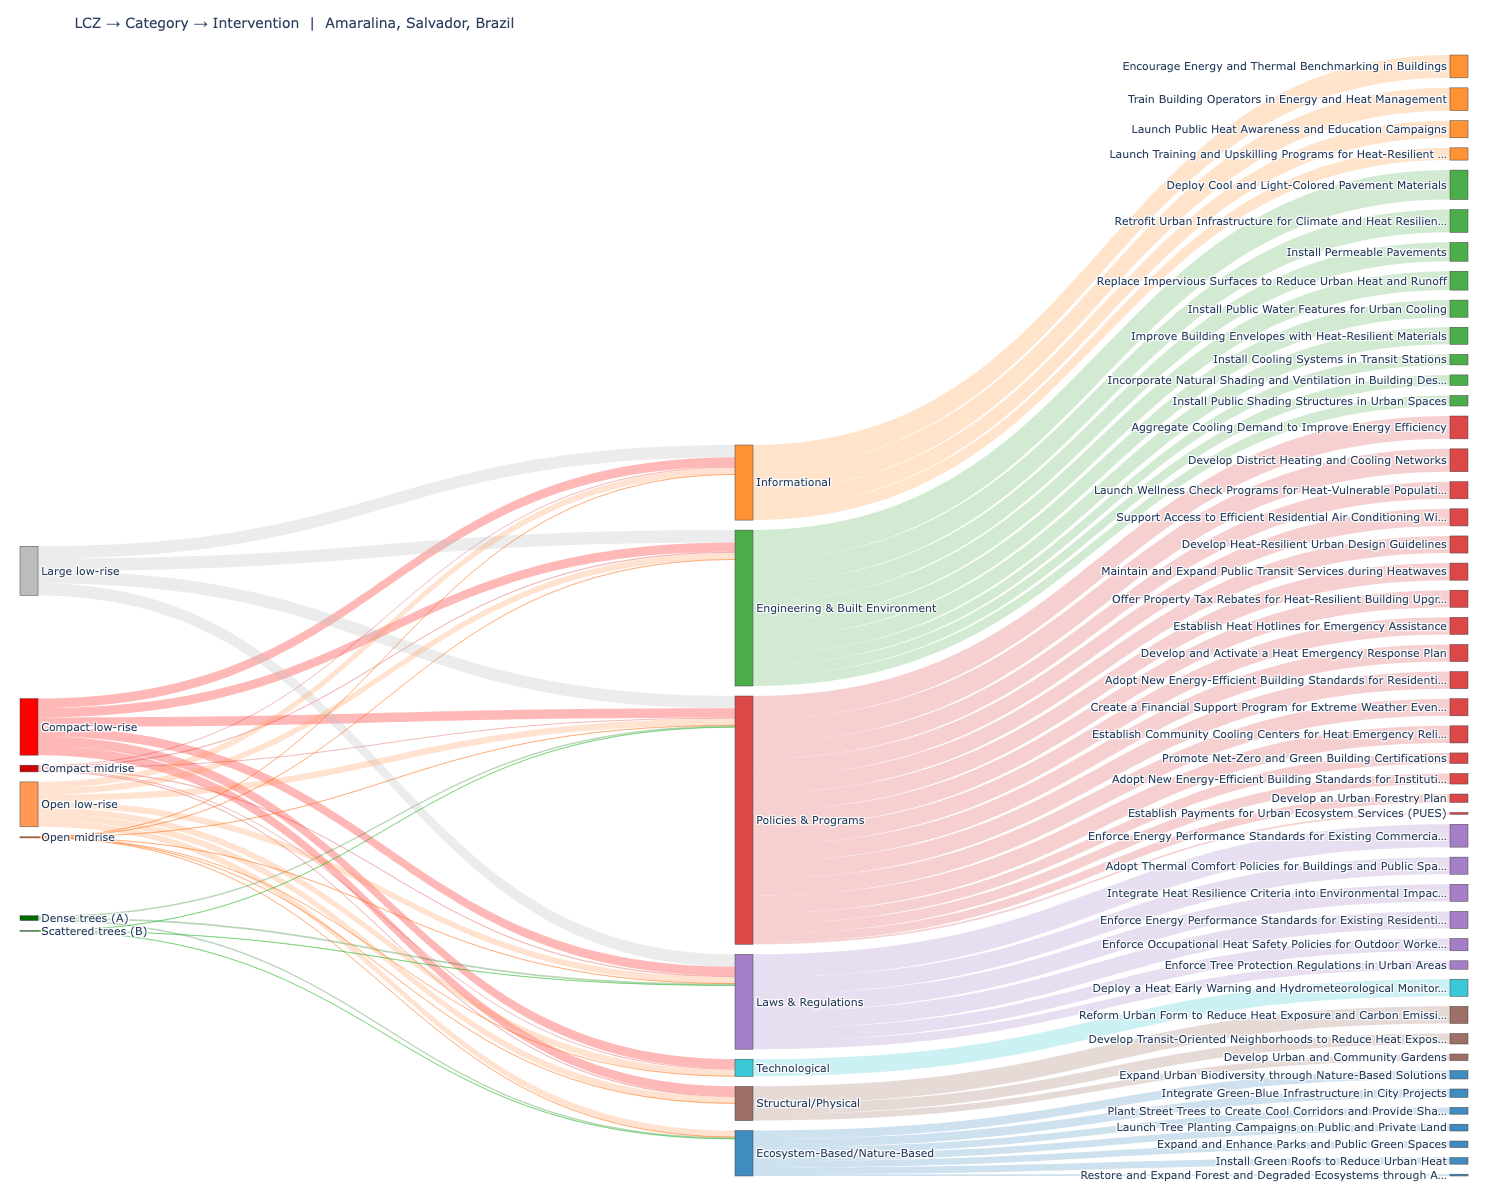

In [67]:
def build_two_step_sankey(
    pixel_counts: pd.DataFrame,
    links_df: pd.DataFrame,
    scores_df: pd.DataFrame,
    action_categories: dict[str, str],
    cat_colors: dict[str, str],
    neighbourhood_label: str,
) -> go.Figure:
    """
    Three-column Sankey: LCZ types → intervention categories → individual interventions.

    LCZ → Category link value  = pixel_count of that LCZ (one link per LCZ×category pair).
    Category → Intervention value = applicable_pixels for that intervention.
    Node colours mirror the category palette so the middle and right columns
    are visually grouped.
    """
    ldf = links_df.copy()
    ldf['category'] = ldf['intervention'].map(action_categories)

    scores_reset = scores_df.reset_index()
    scores_reset['category'] = scores_reset['intervention'].map(action_categories)

    # Category ordering: descending total applicable pixels
    cat_order = (
        scores_reset.groupby('category')['applicable_pixels']
        .sum().sort_values(ascending=False).index.tolist()
    )

    # Node lists and index maps
    lcz_nodes = pixel_counts['lcz_label'].tolist()
    int_nodes  = scores_reset['intervention'].tolist()
    n_lcz = len(lcz_nodes)
    n_cat = len(cat_order)

    lcz_idx = {lbl: i for i, lbl in enumerate(lcz_nodes)}
    cat_idx = {cat: n_lcz + i for i, cat in enumerate(cat_order)}
    int_idx = {row['intervention']: n_lcz + n_cat + i
               for i, row in scores_reset.iterrows()}

    sources, targets, values, link_colors = [], [], [], []

    # ── LCZ → Category ──────────────────────────────────────────────────────
    # One link per (LCZ, category) pair; value = that LCZ's pixel count
    lcz_cat = (
        ldf.groupby(['lcz_label', 'lcz_color', 'category'], as_index=False)
        ['pixel_count'].first()
    )
    for _, row in lcz_cat.iterrows():
        src = lcz_idx.get(row['lcz_label'])
        tgt = cat_idx.get(row['category'])
        if src is None or tgt is None:
            continue
        sources.append(src); targets.append(tgt); values.append(row['pixel_count'])
        h = row['lcz_color'].lstrip('#')
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        link_colors.append(f'rgba({r},{g},{b},0.28)')

    # ── Category → Intervention ──────────────────────────────────────────────
    for _, row in scores_reset.iterrows():
        src = cat_idx.get(row['category'])
        tgt = int_idx.get(row['intervention'])
        if src is None or tgt is None:
            continue
        sources.append(src); targets.append(tgt); values.append(row['applicable_pixels'])
        base = cat_colors.get(row['category'], '#999999')
        h = base.lstrip('#')
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        link_colors.append(f'rgba({r},{g},{b},0.22)')

    # ── Node labels, colours, hover ──────────────────────────────────────────
    def hex_to_rgba(hex_col, alpha=0.85):
        h = hex_col.lstrip('#')
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return f'rgba({r},{g},{b},{alpha})'

    node_labels = (
        lcz_nodes
        + cat_order
        + [_short_label(a) for a in int_nodes]
    )
    node_colors = (
        pixel_counts['lcz_color'].tolist()
        + [hex_to_rgba(cat_colors.get(c, '#999999')) for c in cat_order]
        + [hex_to_rgba(cat_colors.get(scores_reset.loc[i, 'category'], '#999999'))
           for i in range(len(int_nodes))]
    )

    cat_totals = scores_reset.groupby('category')['applicable_pixels'].sum()
    lcz_hover = [f"{r['lcz_label']}<br>{r['pixel_count']:,} px"
                 for _, r in pixel_counts.iterrows()]
    cat_hover  = [f"{c}<br>{cat_totals.get(c,0):,} applicable px" for c in cat_order]
    int_hover  = [f"{r['intervention']}<br>{r['applicable_pixels']:,} px (rank {r['rank']})"
                  for _, r in scores_reset.iterrows()]

    fig = go.Figure(go.Sankey(
        arrangement='snap',
        node=dict(
            pad=10, thickness=18,
            label=node_labels, color=node_colors,
            customdata=lcz_hover + cat_hover + int_hover,
            hovertemplate='%{customdata}<extra></extra>',
        ),
        link=dict(source=sources, target=targets, value=values, color=link_colors),
    ))
    fig.update_layout(
        title=dict(
            text=f'LCZ \u2192 Category \u2192 Intervention  |  {neighbourhood_label}',
            font_size=14,
        ),
        font_size=11,
        height=max(700, 26 * len(int_nodes)),
        margin=dict(l=20, r=20, t=55, b=20),
    )
    return fig


fig2 = build_two_step_sankey(
    pixel_counts, links_df, scores_df,
    ACTION_CATEGORIES, CAT_COLORS,
    NEIGHBOURHOOD['label'],
)
fig2.show()

## Cross-tabulation: all LCZ types × all interventions

Green cell = mapped in the Actions Library. White = no mapping.
Interventions are sorted by category; dashed lines mark category boundaries.
Category labels appear on the right margin.

In [68]:
def build_lcz_intervention_heatmap(
    lcz_interventions: dict,
    action_categories: dict,
    cat_colors: dict,
) -> go.Figure:
    """
    Heatmap: rows = interventions (full names), columns = LCZ types 1-17.
    Green = mapped, white = not mapped.
    Dashed horizontal lines + right-margin labels mark category boundaries.
    """
    all_lcz = list(range(1, 18))

    # Interventions sorted by category then name
    all_actions = sorted(
        {a for v in lcz_interventions.values() for a in v},
        key=lambda a: (action_categories.get(a, 'ZZZ'), a),
    )

    z = [
        [1 if a in lcz_interventions.get(lcz, []) else 0 for lcz in all_lcz]
        for a in all_actions
    ]

    # Single-line column labels — <sub> tags are not supported in axis ticks
    x_labels = [
        f"LCZ {lcz}: {LCZ_META.get(lcz, {}).get('label', '')}"
        for lcz in all_lcz
    ]

    fig = go.Figure(go.Heatmap(
        z=z,
        x=x_labels,
        y=all_actions,          # full names, no truncation
        colorscale=[[0, '#f0f0f0'], [1, '#2ca02c']],
        showscale=False,
        xgap=2,
        ygap=1,
        hovertemplate='<b>%{y}</b><br>%{x}<br>Mapped: %{z}<extra></extra>',
    ))

    n_actions = len(all_actions)

    # ── Category boundary lines and right-margin labels ───────────────────────
    cat_blocks = []
    cur_cat, block_start = None, 0
    for i, action in enumerate(all_actions):
        cat = action_categories.get(action, 'Other')
        if cat != cur_cat:
            if cur_cat is not None:
                cat_blocks.append((cur_cat, block_start, i - 1))
                fig.add_shape(
                    type='line',
                    xref='paper', yref='y',
                    x0=0, x1=1,
                    y0=i - 0.5, y1=i - 0.5,
                    line=dict(color='#666', width=1.5, dash='dot'),
                    layer='above',
                )
            cur_cat, block_start = cat, i
    cat_blocks.append((cur_cat, block_start, n_actions - 1))

    for cat, start, end in cat_blocks:
        fig.add_annotation(
            xref='paper', yref='y',
            x=1.01, y=(start + end) / 2,
            text=f'<b>{cat}</b>',
            showarrow=False,
            xanchor='left',
            font=dict(size=9, color=cat_colors.get(cat, '#444')),
        )

    # ── Layout ────────────────────────────────────────────────────────────────
    fig.update_layout(
        title=dict(text='LCZ \u00d7 Intervention mapping \u2014 full Actions Library', font_size=13),
        height=max(750, 18 * n_actions),
        width=1500,
        xaxis=dict(
            side='top',
            tickfont=dict(size=9),
            tickangle=-50,
        ),
        yaxis=dict(
            tickfont=dict(size=10),
            autorange='reversed',
        ),
        margin=dict(l=580, r=230, t=170, b=20),
    )
    return fig


fig3 = build_lcz_intervention_heatmap(LCZ_INTERVENTIONS, ACTION_CATEGORIES, CAT_COLORS)
fig3.show()

In [72]:
# ── Export cross-tab: all LCZ types × all interventions as Excel ─────────────
import subprocess, sys, io, base64
from IPython.display import HTML, display as ipy_display

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'openpyxl'])
from openpyxl.styles import PatternFill, Font, Alignment

# ── Build the cross-tab DataFrame ────────────────────────────────────────────
all_lcz_export = list(range(1, 18))

all_actions_export = sorted(
    {a for v in LCZ_INTERVENTIONS.values() for a in v},
    key=lambda a: (ACTION_CATEGORIES.get(a, 'ZZZ'), a),
)

x_labels_export = [
    f"LCZ {lcz}: {LCZ_META.get(lcz, {}).get('label', '')}"
    for lcz in all_lcz_export
]

crosstab_df = pd.DataFrame(
    [[1 if a in LCZ_INTERVENTIONS.get(lcz, []) else 0
      for lcz in all_lcz_export]
     for a in all_actions_export],
    index=all_actions_export,
    columns=x_labels_export,
)
crosstab_df.index.name = 'Intervention'
crosstab_df.insert(0, 'Category',
                   [ACTION_CATEGORIES.get(a, '') for a in all_actions_export])

# ── Write Excel into memory ───────────────────────────────────────────────────
buffer = io.BytesIO()
with pd.ExcelWriter(buffer, engine='openpyxl') as writer:
    crosstab_df.to_excel(writer, sheet_name='LCZ_Intervention_Crosstab')
    ws = writer.sheets['LCZ_Intervention_Crosstab']

    green_fill = PatternFill(fill_type='solid', fgColor='2CA02C')
    white_fill = PatternFill(fill_type='solid', fgColor='F0F0F0')

    # openpyxl: row 1 = header; col 1 = Intervention index, col 2 = Category, cols 3+ = LCZ data
    n_rows, n_cols = crosstab_df.shape   # n_cols = 1 (Category) + 17 (LCZ)
    for r in range(2, n_rows + 2):
        for c in range(3, n_cols + 2):
            cell = ws.cell(row=r, column=c)
            cell.fill = green_fill if cell.value == 1 else white_fill

    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(wrap_text=True, horizontal='center')

    ws.freeze_panes = 'C2'
    ws.column_dimensions['A'].width = 70
    ws.column_dimensions['B'].width = 30

# ── Render inline download link ───────────────────────────────────────────────
xlsx_bytes = buffer.getvalue()
b64 = base64.b64encode(xlsx_bytes).decode()
mime = 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
fname = 'lcz_intervention_crosstab.xlsx'

ipy_display(HTML(
    f'<a href="data:{mime};base64,{b64}" download="{fname}" '
    f'style="display:inline-block;margin:8px 0;padding:7px 16px;font-size:14px;'
    f'font-weight:bold;background:#2ca02c;color:white;border-radius:5px;'
    f'text-decoration:none;">⬇ Download {fname}</a>'
    f'<span style="margin-left:12px;font-size:13px;color:#555;">'
    f'{len(all_actions_export)} interventions × {len(all_lcz_export)} LCZ types</span>'
))

crosstab_df



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


,Category,LCZ 1: Compact high-rise,LCZ 2: Compact midrise,LCZ 3: Compact low-rise,LCZ 4: Open high-rise,LCZ 5: Open midrise,LCZ 6: Open low-rise,LCZ 7: Lightweight low-rise,LCZ 8: Large low-rise,LCZ 9: Sparsely built,LCZ 10: Heavy industry,LCZ 11: Dense trees (A),LCZ 12: Scattered trees (B),LCZ 13: Bush / scrub (C),LCZ 14: Low plants (D),LCZ 15: Bare rock / paved (E),LCZ 16: Bare soil / sand (F),LCZ 17: Water (G)
Intervention,,,,,,,,,,,,,,,,,,
Expand Urban Biodiversity through Nature-Based Solutions,Ecosystem-Based/Nature-Based,0,0,0,0,1,1,0,0,0,0,1,1,0,1,0,0,0
Expand and Enhance Parks and Public Green Spaces,Ecosystem-Based/Nature-Based,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
Install Green Roofs to Reduce Urban Heat,Ecosystem-Based/Nature-Based,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
Integrate Green-Blue Infrastructure in City Projects,Ecosystem-Based/Nature-Based,0,0,0,0,1,1,0,0,0,0,1,1,0,1,0,0,0
Launch Tree Planting Campaigns on Public and Private Land,Ecosystem-Based/Nature-Based,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0
Plant Street Trees to Create Cool Corridors and Provide Shading and Cooling,Ecosystem-Based/Nature-Based,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0
Restore and Expand Forest and Degraded Ecosystems through Afforestation,Ecosystem-Based/Nature-Based,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0
Deploy Cool and Light-Colored Pavement Materials,Engineering & Built Environment,1,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0
Improve Building Envelopes with Heat-Resilient Materials,Engineering & Built Environment,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0
